In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pickle

# Importing the dataset
dataset = pd.read_csv(r"C:\Users\Chimni\Projects and Coding\Version Control Systems\Dr-DiagnoSense\DataSets\VIEH_BCP_DATASET.csv")



In [2]:
# Data pre-processing
dataset = dataset.drop(['id', 'Unnamed: 32'], axis=1)

# Checking dataset summary statistics
print(dataset.describe())

# Checking for missing values
print(dataset.isnull().sum())

# Checking unique values in each column
print(dataset.nunique())

# Visualizing correlation between features before one-hot encoding
correlation = dataset.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(correlation, annot=True)
plt.title("Correlation between features before one-hot encoding")
plt.show()


       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

ValueError: could not convert string to float: 'M'

In [ ]:
# Data pre-processing
dataset = dataset.drop(['id', 'Unnamed: 32'], axis=1)

# Checking dataset summary statistics
print(dataset.describe())

# Checking for missing values
print(dataset.isnull().sum())

# Checking unique values in each column
print(dataset.nunique())

# Visualizing correlation between features before one-hot encoding
correlation = dataset.corr()
plt.figure(figsize=(25, 15))
sns.heatmap(correlation, annot=True)
plt.title("Correlation between features before one-hot encoding")
plt.show()


       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

ValueError: could not convert string to float: 'M'

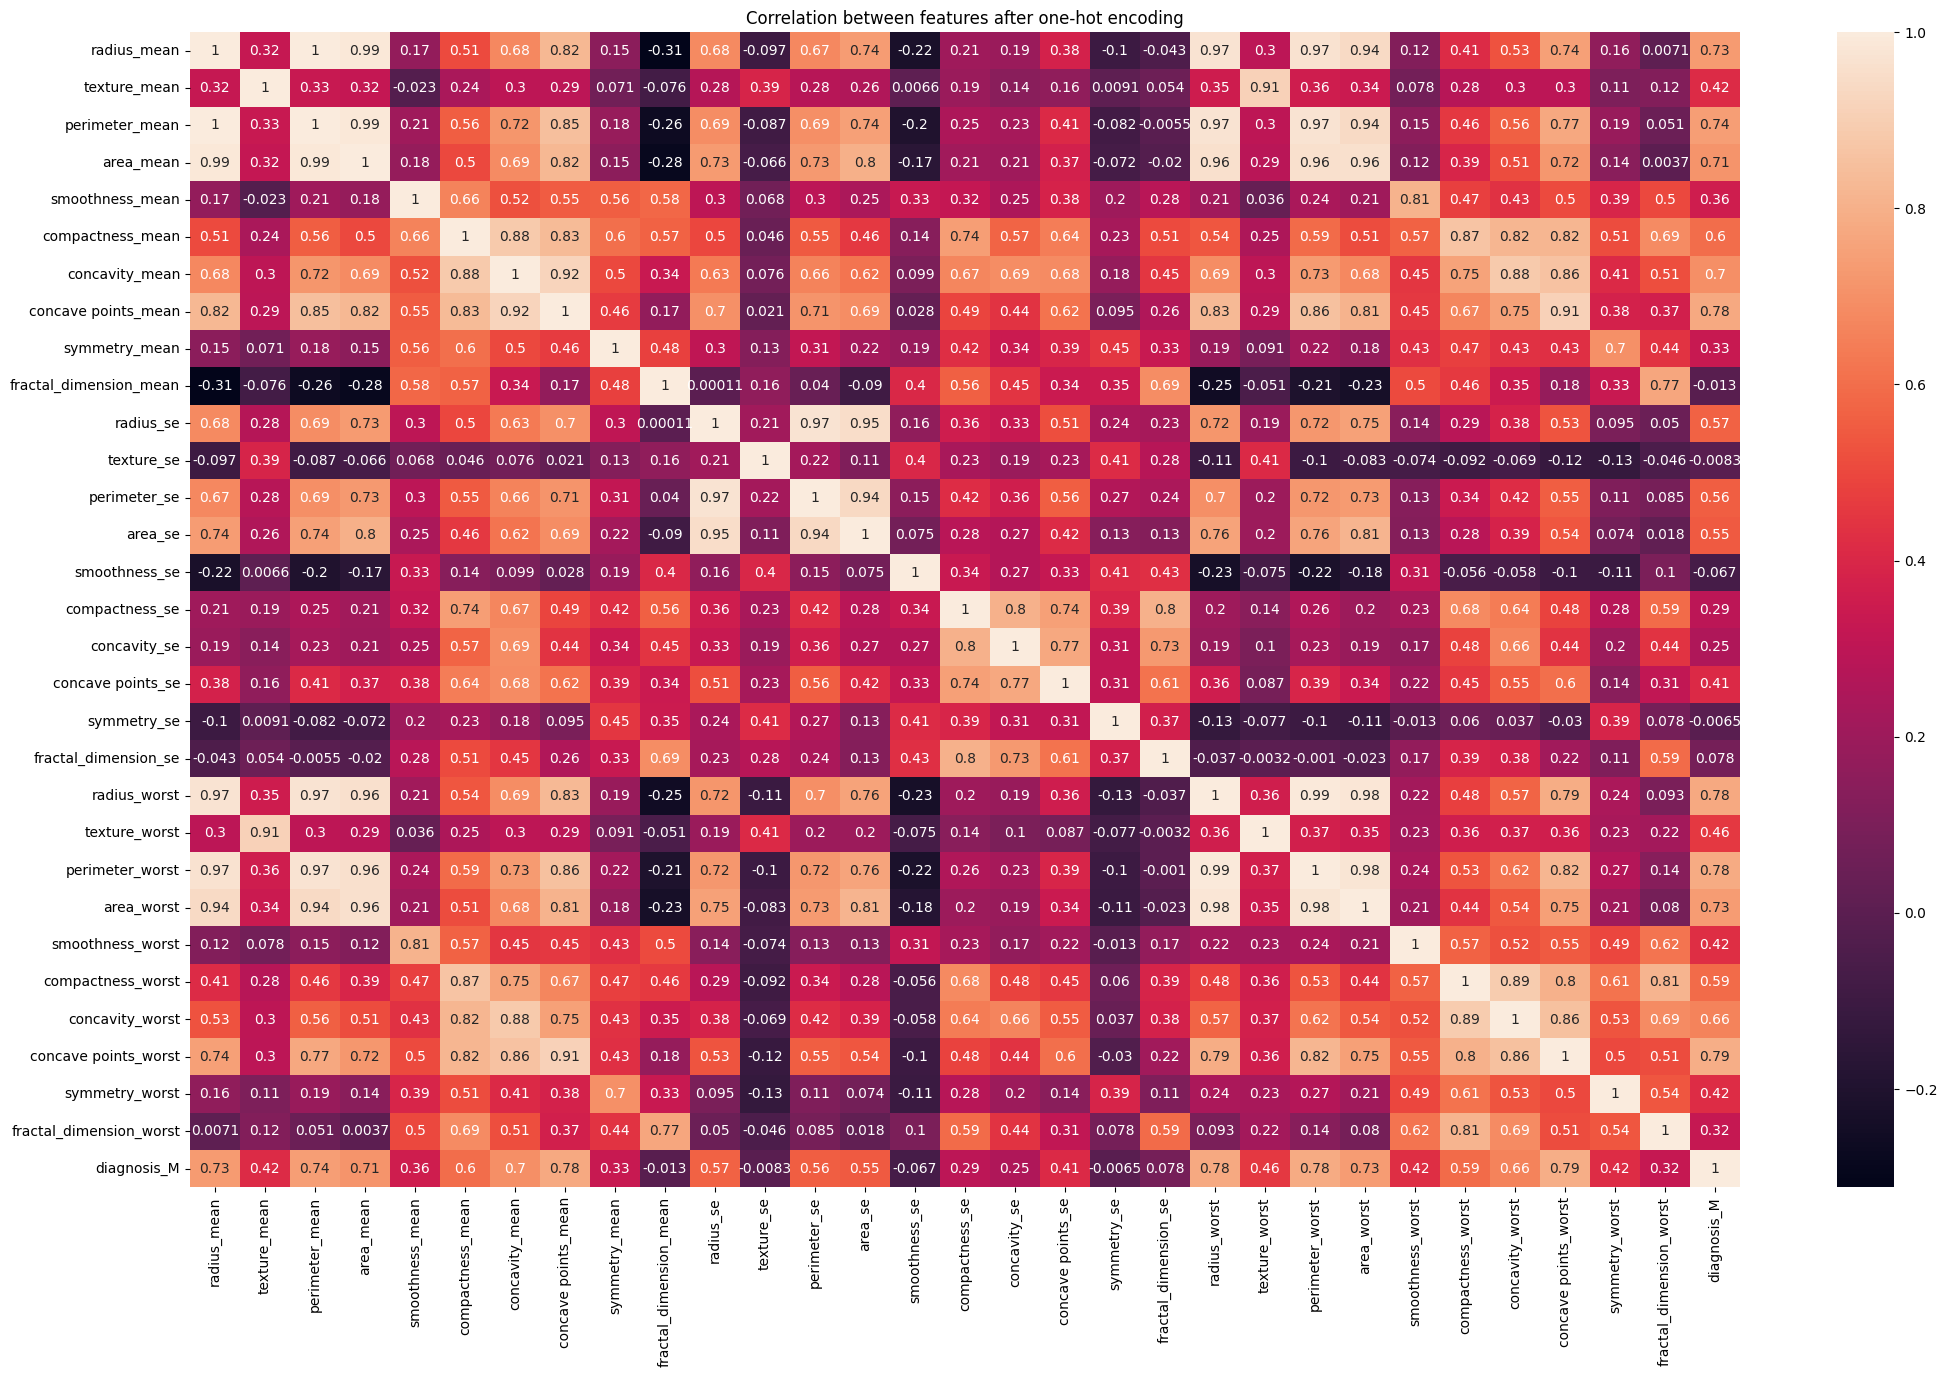

In [3]:
# Perform one-hot encoding on the 'diagnosis' column
dataset = pd.get_dummies(dataset, columns=['diagnosis'], drop_first=True)

# Now, you can calculate the correlation
correlation = dataset.corr()

# Visualizing correlation between features after one-hot encoding
plt.figure(figsize=(25, 15))
sns.heatmap(correlation, annot=True)
plt.title("Correlation between features after one-hot encoding")
plt.show()


In [4]:
# Removing highly correlated features
def remove_highly_correlated_features(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return dataset.drop(col_corr, axis=1)

threshold = 0.72
dataset = remove_highly_correlated_features(dataset, threshold)


In [5]:
# Encoding the target variable
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(dataset['diagnosis_M'])

# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = dataset.drop('diagnosis_M', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


KeyError: 'diagnosis_M'

In [6]:
# Training the logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

# Evaluating the model
y_pred = lr.predict(X_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('Accuracy score:', accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Saving the model
filename = 'breast_cancer_model.pkl'
pickle.dump(lr, open(filename, 'wb'))


NameError: name 'X_train' is not defined